In [2]:
import sys
sys.path.insert(0, "../")

from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from src.networks import EEGConnectivityNet
from src.utils import plot_history
from src.load_data import EEGConnDataset

In [9]:
train_dataset_path = "../data/processed/dataset_train.npz"
test_dataset_path = "../data/processed/dataset_test.npz"
output_folder = "../models/eeg_conn"

In [6]:
def _create_loaders(X_train_raw, X_train_conn, y_train, X_test_raw, X_test_conn, y_test):
    batch_size = 32
    train_ds = EEGConnDataset(X_train_raw, X_train_conn, y_train)
    test_ds = EEGConnDataset(X_test_raw, X_test_conn, y_test)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader


def save_confusion_matrix(labels, preds, out_dir):
    class_labels = ['Rest', 'Elbow', 'Hand', 'Forearm']
    cm = confusion_matrix(labels, preds)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues", 
                xticklabels=class_labels, yticklabels=class_labels, ax=ax)
    ax.set_title('Validation Confusion Matrix (Optimal Weights)')
    ax.set_xlabel('Predicted Target')
    ax.set_ylabel('True Target')
    plt.tight_layout()
    fig.savefig(out_dir / "confusion_matrix.png", dpi=300)
    plt.close(fig)


def train_loop(model, train_loader, test_loader, class_weights, device, out_dir):
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.03)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=6)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    num_epochs = 50 # Bumped to 50 to let the dual branches converge
    best_val_acc = 0.0
    
    final_preds, final_labels = [], []

    print(f"\n{'Epoch':<8} | {'Train Loss':<12} | {'Train Acc':<12} | {'Val Loss':<10} | {'Val Acc':<10}")
    print("-" * 65)

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        # Notice we are unpacking raw AND conn features now
        for batch_raw, batch_conn, labels in train_loader:
            batch_raw, batch_conn, labels = batch_raw.to(device), batch_conn.to(device), labels.to(device)

            if model.training:
                # Add tiny augmentation noise to prevent overfitting
                batch_raw = batch_raw + (torch.randn_like(batch_raw) * 0.1)
                batch_conn = batch_conn + (torch.randn_like(batch_conn) * 0.01)
            
            optimizer.zero_grad()
            # Pass both branches into the forward pass
            outputs = model(batch_raw, batch_conn) 
            loss = criterion(outputs, labels)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item() * labels.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
            
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = 100. * train_correct / train_total

        # --- VALIDATION ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        epoch_preds, epoch_labels = [], []
        
        with torch.no_grad():
            for batch_raw, batch_conn, labels in test_loader:
                batch_raw, batch_conn, labels = batch_raw.to(device), batch_conn.to(device), labels.to(device)
                
                outputs = model(batch_raw, batch_conn)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * labels.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
                
                epoch_preds.extend(predicted.cpu().numpy())
                epoch_labels.extend(labels.cpu().numpy())
                
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = 100. * val_correct / val_total
        
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        
        scheduler.step(epoch_val_loss)
        
        print(f"{epoch+1:<8} | {epoch_train_loss:<12.4f} | {epoch_train_acc:<10.2f}% | {epoch_val_loss:<10.4f} | {epoch_val_acc:<10.2f}%")

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            final_preds = epoch_preds
            final_labels = epoch_labels
            torch.save(model.state_dict(), out_dir / "best_dual_branch.pth")
            print(f"Peak weights secured! ({best_val_acc:.2f}%)")

    return history, np.array(final_preds), np.array(final_labels)


In [10]:

out_dir = Path(output_folder)
out_dir.mkdir(parents=True, exist_ok=True)

# Load the new datasets containing the X_conn feature
train_data = np.load(train_dataset_path)
X_train_raw, X_train_conn, y_train = train_data['X'], train_data['X_conn'], train_data['y']

test_data = np.load(test_dataset_path)
X_test_raw, X_test_conn, y_test = test_data['X'], test_data['X_conn'], test_data['y']

train_loader, test_loader = _create_loaders(X_train_raw, X_train_conn, y_train, X_test_raw, X_test_conn, y_test)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the new Dual-Branch Architecture
model = EEGConnectivityNet(n_channels=21, n_classes=4, sfreq=128).to(device)

# Handle class imbalances
_, counts = np.unique(y_train, return_counts=True)
class_weights = 1.0 / torch.tensor(counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum()
class_weights = class_weights.to(device)

# Execute training loop
history, all_preds, all_labels = train_loop(model, train_loader, test_loader, class_weights, device, out_dir)

# Save learning curves using your util function
fig = plot_history(history)
if fig is not None:
    fig.savefig(out_dir / "learning_curves.png", dpi=300, bbox_inches='tight')
    plt.close(fig)

# Save the normalized confusion matrix
save_confusion_matrix(all_labels, all_preds, out_dir)

print(f"\nTraining Complete. All assets and peak weights saved to {out_dir}/")



Epoch    | Train Loss   | Train Acc    | Val Loss   | Val Acc   
-----------------------------------------------------------------
1        | 1.3173       | 34.07     % | 1.1887     | 46.15     %
Peak weights secured! (46.15%)
2        | 1.2090       | 44.57     % | 1.1379     | 48.54     %
Peak weights secured! (48.54%)
3        | 1.1645       | 47.17     % | 1.1179     | 51.19     %
Peak weights secured! (51.19%)
4        | 1.1425       | 48.64     % | 1.1069     | 51.06     %
5        | 1.1446       | 49.25     % | 1.0849     | 52.79     %
Peak weights secured! (52.79%)
6        | 1.1173       | 50.96     % | 1.0807     | 52.39     %
7        | 1.1117       | 51.69     % | 1.0643     | 54.64     %
Peak weights secured! (54.64%)
8        | 1.1003       | 53.56     % | 1.0606     | 54.77     %
Peak weights secured! (54.77%)
9        | 1.0891       | 54.85     % | 1.0572     | 54.24     %
10       | 1.0842       | 53.37     % | 1.0579     | 53.85     %
11       | 1.0855       | 53.51 

KeyboardInterrupt: 

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import mne
from pathlib import Path

def plot_topological_hubs(X_conn, y, out_dir):
    """
    Computes Node Degrees from Tangent Space connectivity features and 
    plots MNE head-interpolated topograms for Movement minus Rest.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    class_names = {0: 'Elbow', 1: 'Hand', 2: 'Forearm', 3: 'Rest'}
    movements = ['Elbow', 'Hand', 'Forearm']

    # Exact channel layout of your 21-channel setup
    ch_names = ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 
                'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 
                'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6']

    # Create a standard MNE info structure using a 10-20 montage for 3D coordinates
    info = mne.create_info(ch_names=ch_names, sfreq=128, ch_types='eeg')
    montage = mne.channels.make_standard_montage('standard_1020')
    info.set_montage(montage)

    def rebuild_symmetric_matrix(flat_vector, n_channels=21):
        """Rebuilds the symmetric 21x21 matrix from the 210-length upper triangle."""
        matrix = np.zeros((n_channels, n_channels))
        triu_idx = np.triu_indices(n_channels, k=1)
        matrix[triu_idx] = flat_vector
        # Mirror to lower triangle to make it symmetric
        matrix = matrix + matrix.T
        return matrix

    # Isolate the Beta Band (last 210 features) which directly tracks motor activations
    # If you want Alpha instead, use X_conn[:, :210]
    beta_tangent = X_conn[:, 210:]

    # Compute Grand Average Matrices per Class
    avg_matrices = {}
    for class_idx, class_label in class_names.items():
        class_data = beta_tangent[y == class_idx]
        avg_matrices[class_label] = rebuild_symmetric_matrix(np.mean(class_data, axis=0))

    # Setup the Subplots for Topogram Maps
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Beta Band (22Hz) Functional Hub Activation Zones: Movement minus Rest', 
                 fontsize=16, fontweight='bold', y=1.05)

    # Find a unified scale max across all deltas to ensure colorbar honesty
    all_deltas = [avg_matrices[m] - avg_matrices['Rest'] for m in movements]
    max_degree = max([np.sum(np.abs(delta), axis=0).max() for delta in all_deltas])

    for i, movement in enumerate(movements):
        # Delta: Movement map isolated relative to the Rest baseline
        delta_matrix = avg_matrices[movement] - avg_matrices['Rest']
        
        # CRITICAL TRANSFORMATION: Compute Node Degree (Sum of connection weights per channel)
        # This collapses the 2D matrix back down into a 21-element array for spatial plotting
        node_degree = np.sum(delta_matrix, axis=0)
        
        # Plot the 2D topomap with head silhouette interpolation
        im, _ = mne.viz.plot_topomap(
            data=node_degree,
            pos=info,
            axes=axes[i],
            cmap='RdBu_r',                  # Red = Hub activation, Blue = Hub suppression
            vlim=(-max_degree, max_degree), # Balance scale symmetrically around 0
            contours=6,                     # Number of contour lines to draw
            show=False,
            sensors=True,                   # Draw dots for electrode positions
            extrapolate='head'
        )
        
        axes[i].set_title(f'{movement} Pattern Maps', fontsize=13, fontweight='bold', pad=12)

    # Add a single unified colorbar to the right side of the figure
    cbar_ax = fig.add_axes([0.95 , 0.15, 0.015, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('Hub Communication Strength Delta (Node Degree)', fontsize=11, fontweight='bold')

    plt.tight_layout()
    
    # Save the output
    save_path = out_dir / "connectivity_topomaps.png"
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"Topomaps successfully generated and saved to {save_path}")

In [16]:
plot_topological_hubs(X_train_conn, y_train, out_dir)

/tmp/ipykernel_7965/1899579312.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Topomaps successfully generated and saved to ../models/eeg_conn/connectivity_topomaps.png


Extracting bottleneck features from test set...
Running t-SNE (this may take a minute)...


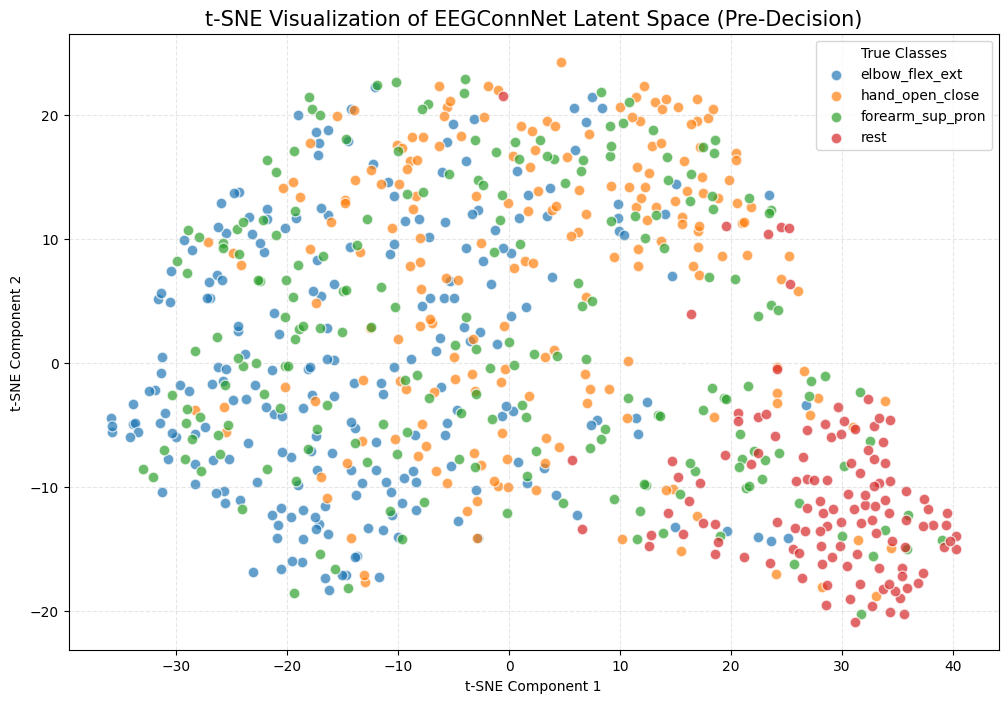

In [17]:
from sklearn.manifold import TSNE

from src.config import CLASS_NAMES

def get_bottleneck_features(model, loader, device):
    model.eval()
    features = []
    labels_list = []
    
    with torch.no_grad():
        for raw_inputs, conn_inputs, labels in loader:
            raw_inputs = raw_inputs.to(device)
            conn_inputs = conn_inputs.to(device)
            
            x1 = model.temporal_conv(raw_inputs)
            x1 = model.spatial_conv(x1)
            x1 = model.separator_conv(x1)
            x1 = torch.flatten(x1, 1) # Yields 160 dimensions
            x1_compressed = model.raw_compressor(x1) # Squeezed to 32 dimensions
            
            # Process Connectivity Branch
            x2 = model.conn_encoder(conn_inputs) # Yields 32 dimensions
            
            # Compute Dynamic Attention Weights
            combined_features = torch.cat((x1_compressed, x2), dim=1) # 64 dimensions
            attn_weights = model.attention_gate(combined_features)     # Shape: (Batch, 2)
            
            #  Apply Attention Weights to Blend Modalities
            w_raw = attn_weights[:, 0].unsqueeze(1)
            w_conn = attn_weights[:, 1].unsqueeze(1)
            
            fused_representation = (w_raw * x1_compressed) + (w_conn * x2)
            
            features.append(fused_representation.cpu().numpy())
            labels_list.append(labels.numpy())
            
    return np.concatenate(features), np.concatenate(labels_list)

def plot_feature_clusters(model, test_loader, device, class_names):
    # Extract features
    print("Extracting bottleneck features from test set...")
    features, labels = get_bottleneck_features(model, test_loader, device)
    
    # Apply t-SNE
    print("Running t-SNE (this may take a minute)...")
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
    features_2d = tsne.fit_transform(features)
    
    plt.figure(figsize=(12, 8))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Distinct professional colors
    
    for i, class_name in enumerate(class_names):
        indices = np.where(labels == i)
        plt.scatter(
            features_2d[indices, 0], 
            features_2d[indices, 1], 
            c=colors[i], 
            label=class_name,
            alpha=0.7, 
            edgecolors='w', 
            s=60
        )
    
    plt.title("t-SNE Visualization of EEGConnNet Latent Space (Pre-Decision)", fontsize=15)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend(title="True Classes", loc='best')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()


plot_feature_clusters(model, test_loader, device, CLASS_NAMES)